In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

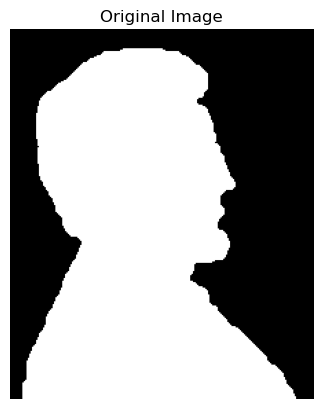

In [2]:
img = cv2.imread("licoln.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

(a) Compare different edge detection algorithms implemented in spatial domain.

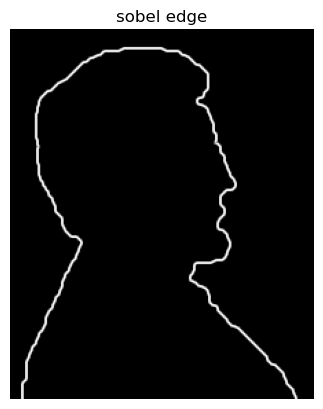

In [7]:
sobel_x = np.array([[1,0,-1],
                    [2,0,-2],
                    [1,0,-1]])
sobel_y = np.array([[1,2,1],
                    [0,0,0],
                    [-1,-2,-1]])
sobel_kernel_x = ndimage.convolve(img, sobel_x)
sobel_kernel_y = ndimage.convolve(img, sobel_y)
sobel_img = np.sqrt(sobel_kernel_x**2 + sobel_kernel_y**2)

plt.imshow(sobel_img, cmap='gray')
plt.title('sobel edge')
plt.axis('off')
plt.show()

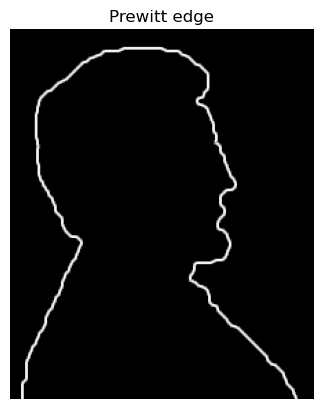

In [8]:
prewitt_x = np.array(
    [
        [1,0,-1],
        [1,0,-1],
        [1,0,-1]
    ])
prewitt_y = np.array(
    [
        [1,1,1],
        [0,0,0],
        [-1,-1,-1]
    ])
prewitt_kernel_x = ndimage.convolve(img, prewitt_x)
prewitt_kernel_y = ndimage.convolve(img, prewitt_y)
prewitt_img = np.sqrt(prewitt_kernel_x**2 + prewitt_kernel_y**2)

plt.imshow(prewitt_img, cmap='gray')
plt.title('Prewitt edge')
plt.axis('off')
plt.show()

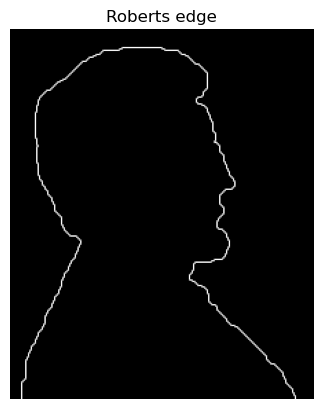

In [9]:
roberts_x = np.array(
    [
        [1, 0],
        [0, -1]
    ])
roberts_y = np.array(
    [
        [0, 1], 
        [-1, 0]
    ])
roberts_kernel_x = ndimage.convolve(img, roberts_x)
roberts_kernel_y = ndimage.convolve(img, roberts_y)

roberts_img = np.sqrt(roberts_kernel_x**2 + roberts_kernel_y**2)
plt.imshow(roberts_img, cmap='gray')
plt.title('Roberts edge')
plt.axis('off')
plt.show()

(b) Illustrate the segmentation based on gray level.

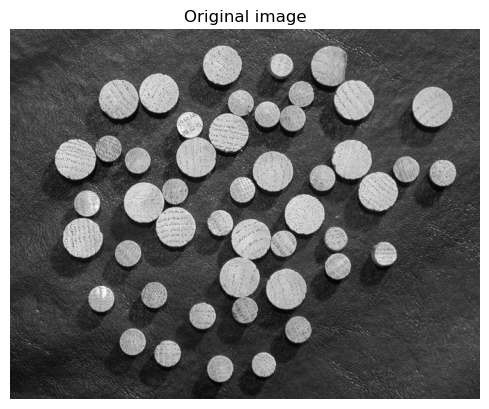

In [10]:
img = cv2.imread('wood_dowels.tif', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()

In [13]:
def simple_threshold(img, value, max_value):
    result = np.zeros_like(img)
    result[img>value] = max_value
    result[img<=value] = 0
    return result

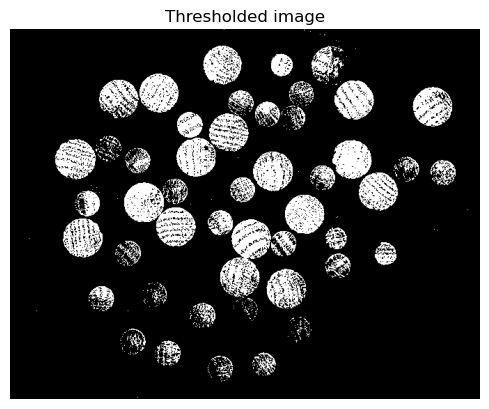

In [15]:
th = simple_threshold(img, 180, 255)
plt.imshow(th, cmap='gray')
plt.title('Thresholded image')
plt.axis('off')
plt.show()

Global thresholding

In [16]:
def global_thresholding(img, epsion=0.5):
    a = np.mean(img)
    while True:
        g1 = img[img>a]
        g2 = img[img<=a]

        if len(g1)==0:
            m1 = 0
        else:
            m1 = np.mean(g1)
        if len(g2)==0:
            m2 = 0
        else:
            m2 = np.mean(g2)

        a_new = (m1+m2)/2

        if abs(a-a_new)<=epsion:
            break
        a = a_new
    return a


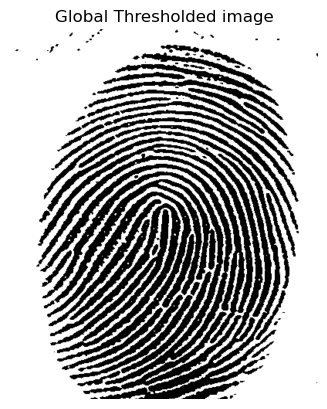

In [17]:
img = cv2.imread('noisy_fingerprint.tif', cv2.IMREAD_GRAYSCALE)

t = global_thresholding(img, 0.5)
global_img = np.zeros_like(img)
global_img[img>t] = 255
global_img[img<=t]= 0

plt.imshow(global_img, cmap='gray')
plt.title('Global Thresholded image')
plt.axis('off')
plt.show()

(c) Demonstrate the segmentation by adaptive thresholding.

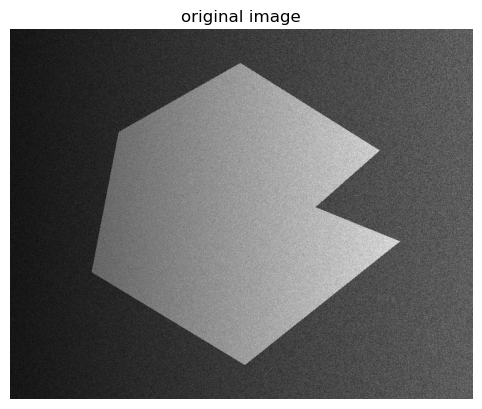

In [18]:
img = cv2.imread("septagon_noisy_shaded.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title('original image')
plt.axis('off')
plt.show()

In [19]:
def adaptive_thresholding(img, max_value, block_size, c):
    if block_size%2==0:
        return print("block size must be odd and >=3")
    pad = block_size//2
    padded_img = np.pad(img, pad, mode='constant', constant_values=0)
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            block = padded_img[i:i+block_size, j: j+block_size]
            local_mean = np.mean(block)
            if img[i,j]>(local_mean-c):
                output[i,j]=max_value
            else:
                output[i,j]=0
    return output

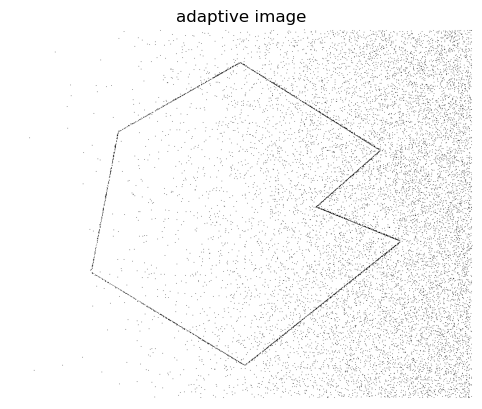

In [20]:
adp_img = adaptive_thresholding(img, 255, 5, 10)
plt.imshow(adp_img, cmap='gray')
plt.title('adaptive image')
plt.axis('off')
plt.show()

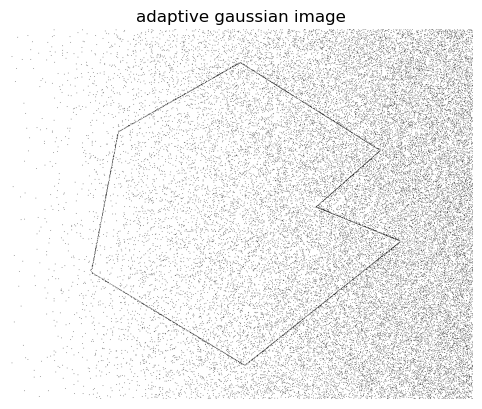

In [21]:
adp_gaussian_img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 5, 7)
plt.imshow(adp_gaussian_img, cmap='gray')
plt.title('adaptive gaussian image')
plt.axis('off')
plt.show()